# Giai đoạn 2 — Tách Train / Test và thiết kế Cross-Validation

**Đầu vào:** `data/raw/khao_sat_dinh_huong_nganh_hoc_clean.csv` — 766 phiếu khảo sát sinh viên HUIT.
Mỗi phiếu gồm: ngành đang học, giới tính, tổ hợp thi, **10 câu Likert (thang 1–5)** về sở thích và
tính cách, điểm 3 môn của tổ hợp, và mục tiêu nghề nghiệp.

**Đầu ra:**

| File | Nội dung |
|---|---|
| `khaosat_train.csv` | Phần train **thật** — dùng cho Giai đoạn 3, 4, 5 |
| `khaosat_test_KHONG_DUNG_TOI.csv` | **Test khoá lại** — chỉ mở 1 lần ở cuối Giai đoạn 8 |
| `cv_folds_real.json` | Chỉ số các fold Cross-Validation trên phần train thật |
| `nganh_khoi_mapping.json` | Bảng ánh xạ chuẩn 39 ngành → 7 khối, dùng chung cho mọi giai đoạn sau |

## Ba nguyên tắc thiết kế

**1. Tách test đầu tiên, trước mọi bước xử lý.** Không giai đoạn nào từ 3 đến 7 được đọc file test.

**2. Tập validation phải là dòng THẬT.** Chỉ có ~574 dòng thật cho 39 ngành nên không thể cắt thêm
một tập validation cố định (quá phí dữ liệu). Thay vào đó dùng **K-Fold lặp lại** trên phần train.
Dữ liệu tổng hợp sinh ở Giai đoạn 4 chỉ được thêm vào **phía TRAIN của từng fold**, không bao giờ vào VAL.

**3. Chia theo `nganh_hoc` (39 lớp)** để mọi ngành đều xuất hiện ở cả train, test và mọi fold.

```
766 phiếu khảo sát
  │  loại phiếu "điền đại" (straight-lining)
  ▼
676 phiếu chất lượng
  │  chia phân tầng 85 / 15 theo ngành
  ├────────────────────────►  TEST 102 phiếu  ← KHOÁ LẠI đến Giai đoạn 8
  ▼
TRAIN 574 phiếu
  │  RepeatedStratifiedKFold(5 fold × 3 lần) = 15 lần đo
  ▼
mỗi fold:  VAL   = phần thật của fold        → mọi chỉ số đo tại đây
           TRAIN = phần thật còn lại + toàn bộ dữ liệu tổng hợp
```

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from pathlib import Path
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

RAW_PATH   = Path("../data/raw/khao_sat_dinh_huong_nganh_hoc_clean.csv")
OUTPUT_DIR = Path("../data/processed/02_split")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED, TEST_SIZE, N_SPLITS, N_REPEATS = 42, 0.15, 5, 3
np.random.seed(SEED)

df_raw = pd.read_csv(RAW_PATH)
print(f"Tổng số phiếu khảo sát : {len(df_raw):,}")
print(f"Số ngành               : {df_raw['nganh_hoc'].nunique()}")
print(f"Số cột                 : {df_raw.shape[1]}")
df_raw.head(3)

Tổng số phiếu khảo sát : 766
Số ngành               : 39
Số cột                 : 27


,thoi_gian,nganh_hoc,gioi_tinh,to_hop_thi,likert_nang_dong,likert_huong_noi,likert_sang_tao,likert_logic,likert_to_mo,likert_thi_nghiem,...,diem_Toan,diem_Gdktpl,diem_Tin,diem_Su,diem_Ly,diem_Hoa,diem_Sinh,muc_tieu_ma,muc_tieu_nhan,ghi_chu_thieu_du_lieu
0,7/18/2026 12:09,Công nghệ thông tin,Nam,"A01 (Toán, Lý, Anh)",2,4,5,3,5,3,...,7.8,NaN,NaN,NaN,7.3,NaN,NaN,1,Đi làm,NaN
1,7/18/2026 13:07,Công nghệ thông tin,Nam,"A01 (Toán, Lý, Anh)",2,4,3,5,4,2,...,7.5,NaN,NaN,NaN,8.5,NaN,NaN,1,Đi làm,NaN
2,7/18/2026 13:08,Công nghệ thông tin,Nam,"A01 (Toán, Lý, Anh)",3,3,3,3,3,3,...,8.3,NaN,NaN,NaN,7.3,NaN,NaN,1,Đi làm,NaN


## 1. Bảng ánh xạ chuẩn — 39 ngành → 7 khối ngành

Đây là **nguồn duy nhất** của bảng ánh xạ. Các giai đoạn sau đọc lại từ file JSON thay vì chép lại,
tránh tình trạng mỗi notebook một bản rồi lệch nhau.

In [2]:
TAXONOMY = {   # tên ngành -> (mã ngành, mã khối)
    "Công nghệ thông tin": (7480201, 0), "An toàn thông tin": (7480202, 0),
    "Khoa học dữ liệu": (7460108, 0), "Trí tuệ nhân tạo": (7480107, 0),
    "Quản trị kinh doanh": (7340101, 1), "Marketing": (7340115, 1),
    "Kinh doanh quốc tế": (7340120, 1), "Thương mại điện tử": (7340122, 1),
    "Kế toán": (7340301, 1), "Tài chính ngân hàng": (7340201, 1),
    "Công nghệ tài chính": (7340205, 1), "Logistics và quản lý chuỗi cung ứng": (7510605, 1),
    "Quản lý Công nghiệp": (7510601, 1), "Kinh doanh thời trang và dệt may": (7340123, 1),
    "Quản trị dịch vụ du lịch và lữ hành": (7810103, 2), "Quản trị khách sạn": (7810201, 2),
    "Quản trị nhà hàng và dịch vụ ăn uống": (7810202, 2), "Du lịch": (7810101, 2),
    "Khoa học dinh dưỡng và ẩm thực": (7819009, 2), "Khoa học chế biến món ăn": (7819010, 2),
    "Công nghệ kỹ thuật cơ điện tử": (7510203, 3), "Công nghệ chế tạo máy": (7510202, 3),
    "Kỹ thuật nhiệt": (7520115, 3), "Công nghệ kỹ thuật điện - điện tử": (7510301, 3),
    "Công nghệ kỹ thuật điều khiển và TĐH": (7510303, 3), "Công nghệ kỹ thuật hóa học": (7510401, 3),
    "Công nghệ vật liệu": (7510402, 3), "Công nghệ dệt, may": (7540204, 3),
    "Công nghệ thực phẩm": (7540101, 4), "Đảm bảo chất lượng và an toàn thực phẩm": (7540106, 4),
    "Quản trị kinh doanh thực phẩm": (7340129, 4), "Công nghệ chế biến thủy sản": (7540105, 4),
    "Công nghệ sinh học": (7420201, 4), "Công nghệ kỹ thuật môi trường": (7510406, 4),
    "Quản lý tài nguyên và môi trường": (7850101, 4),
    "Luật": (7380101, 5), "Luật kinh tế": (7380107, 5),
    "Ngôn ngữ Anh": (7220201, 6), "Ngôn ngữ Trung Quốc": (7220204, 6),
}
TEN_KHOI = {
    0: "CNTT & Máy tính", 1: "Kinh doanh & Quản lý", 2: "Du lịch, Khách sạn & Ẩm thực",
    3: "Kỹ thuật & Công nghệ", 4: "Thực phẩm, Sinh học & Môi trường", 5: "Luật", 6: "Ngoại ngữ",
}
TEN_TO_MA     = {t: m for t, (m, _) in TAXONOMY.items()}
MA_TO_TEN     = {m: t for t, m in TEN_TO_MA.items()}
NGANH_TO_KHOI = {m: k for _, (m, k) in TAXONOMY.items()}

assert len(TEN_TO_MA) == 39 and len(set(TEN_TO_MA.values())) == 39
assert set(NGANH_TO_KHOI.values()) == set(range(7))
la = set(df_raw["nganh_hoc"]) - set(TEN_TO_MA)
assert not la, f"Ngành trong khảo sát chưa có trong bảng ánh xạ: {la}"

with open(OUTPUT_DIR / "nganh_khoi_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"ten_to_ma": TEN_TO_MA,
               "ma_to_ten": {str(k): v for k, v in MA_TO_TEN.items()},
               "nganh_to_khoi": {str(k): v for k, v in NGANH_TO_KHOI.items()},
               "ten_khoi": {str(k): v for k, v in TEN_KHOI.items()}}, f,
              ensure_ascii=False, indent=2)

print("BẢNG 2.1 — Cơ cấu 7 khối ngành\n")
for k in range(7):
    ds = [t for t, (_, kk) in TAXONOMY.items() if kk == k]
    print(f"  Khối {k} · {TEN_KHOI[k]:<34} {len(ds):>2} ngành")
print(f"\n✅ Đã lưu nganh_khoi_mapping.json")

BẢNG 2.1 — Cơ cấu 7 khối ngành

  Khối 0 · CNTT & Máy tính                     4 ngành
  Khối 1 · Kinh doanh & Quản lý               10 ngành
  Khối 2 · Du lịch, Khách sạn & Ẩm thực        6 ngành
  Khối 3 · Kỹ thuật & Công nghệ                8 ngành
  Khối 4 · Thực phẩm, Sinh học & Môi trường    7 ngành
  Khối 5 · Luật                                2 ngành
  Khối 6 · Ngoại ngữ                           2 ngành

✅ Đã lưu nganh_khoi_mapping.json


## 2. Lọc phiếu "điền đại" (straight-lining)

**Straight-lining** là hiện tượng người trả lời chọn cùng một mức cho cả 10 câu Likert
(ví dụ toàn số 3). Đây là dấu hiệu kinh điển của phiếu điền cho có — nếu giữ lại, Giai đoạn 3
sẽ học phải phân phối sai và Giai đoạn 4 sẽ nhân bản cái sai đó lên hàng nghìn dòng.

Phép lọc này **theo từng dòng và xác định** (không ước lượng thống kê nào từ dữ liệu) nên áp dụng
trước khi tách train/test vẫn **không gây rò rỉ**.

In [3]:
LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
NHAN_LIKERT = ["Năng động", "Hướng nội", "Sáng tạo", "Tư duy logic", "Tò mò",
               "Thí nghiệm", "Môi trường", "Dinh dưỡng", "Tranh luận", "Thiết kế"]
DIEM_COLS = ["diem_Toan", "diem_Ly", "diem_Hoa", "diem_Anh", "diem_Van",
             "diem_Su", "diem_Sinh", "diem_Dia", "diem_Gdktpl", "diem_Tin"]

assert df_raw[LIKERT_COLS].notna().all().all(), "Likert không được có ô trống"
assert df_raw[LIKERT_COLS].stack().between(1, 5).all(), "Likert phải trong [1, 5]"

df = df_raw.copy()
df["to_hop_thi"]     = df["to_hop_thi"].astype(str).str.split().str[0]
df["ma_nganh"]       = df["nganh_hoc"].map(TEN_TO_MA)
df["ma_khoi_nganh"]  = df["ma_nganh"].map(NGANH_TO_KHOI)
df["ten_khoi_nganh"] = df["ma_khoi_nganh"].map(TEN_KHOI)

straight = df[LIKERT_COLS].nunique(axis=1) == 1
low_std  = df[LIKERT_COLS].std(axis=1) <= 0.3
nhieu    = straight | low_std
df_clean = df[~nhieu].copy().reset_index(drop=True)

print(f"Phiếu chọn cùng một mức cho cả 10 câu : {int(straight.sum()):>4} phiếu")
print(f"Phiếu có độ lệch chuẩn ≤ 0.3          : {int(low_std.sum()):>4} phiếu")
print(f"Chỉ bị bắt bởi tiêu chí độ lệch chuẩn : {int((low_std & ~straight).sum()):>4} phiếu")
print(f"  → hai tiêu chí bắt đúng cùng một nhóm\n")
print(f"Trước lọc : {len(df):>4} phiếu")
print(f"Bị loại   : {int(nhieu.sum()):>4} phiếu ({nhieu.mean():.1%})")
print(f"Sau lọc   : {len(df_clean):>4} phiếu, đủ {df_clean['nganh_hoc'].nunique()} ngành")

Phiếu chọn cùng một mức cho cả 10 câu :   90 phiếu
Phiếu có độ lệch chuẩn ≤ 0.3          :   90 phiếu
Chỉ bị bắt bởi tiêu chí độ lệch chuẩn :    0 phiếu
  → hai tiêu chí bắt đúng cùng một nhóm

Trước lọc :  766 phiếu
Bị loại   :   90 phiếu (11.7%)
Sau lọc   :  676 phiếu, đủ 39 ngành


   💾 Đã lưu hình: hinh_2_1_loc_phieu_dien_dai.png


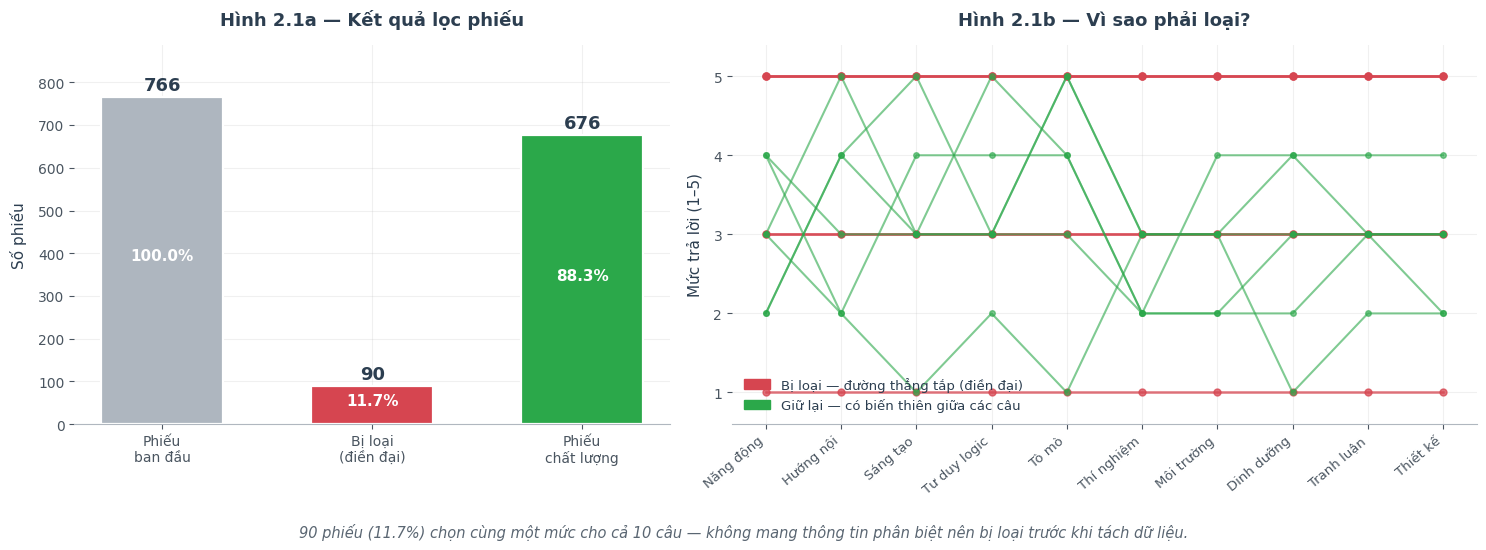

In [4]:
# ═══════════ HÌNH 2.1 — Lọc phiếu điền đại ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})

# (a) Trước / sau lọc
ax = axes[0]
gt = [len(df), int(nhieu.sum()), len(df_clean)]
ten = ["Phiếu\nban đầu", "Bị loại\n(điền đại)", "Phiếu\nchất lượng"]
ax.bar(ten, gt, color=[C_XAM, C_THAT, C_GA], width=0.58, edgecolor="white", linewidth=1.6)
for i, v in enumerate(gt):
    ax.text(i, v + 16, f"{v:,}", ha="center", fontsize=13, fontweight="bold", color=C_DAM)
    ax.text(i, v * 0.5, f"{v/len(df):.1%}", ha="center", fontsize=11,
            color="white", fontweight="bold")
ax.set_ylabel("Số phiếu"); ax.set_ylim(0, len(df) * 1.16)
ax.set_title("Hình 2.1a — Kết quả lọc phiếu")
ax.set_axisbelow(True)

# (b) Minh hoạ: phiếu bị loại trông như thế nào
ax = axes[1]
vd_loai = df[nhieu][LIKERT_COLS].head(6).values
vd_giu  = df[~nhieu][LIKERT_COLS].head(6).values
for i, hang in enumerate(vd_loai):
    ax.plot(range(10), hang, "o-", color=C_THAT, alpha=0.75, lw=1.8, ms=5)
for i, hang in enumerate(vd_giu):
    ax.plot(range(10), hang, "o-", color=C_GA, alpha=0.6, lw=1.5, ms=4)
ax.set_xticks(range(10)); ax.set_xticklabels(NHAN_LIKERT, rotation=40, ha="right", fontsize=9.5)
ax.set_yticks(range(1, 6)); ax.set_ylabel("Mức trả lời (1–5)"); ax.set_ylim(0.6, 5.4)
ax.set_title("Hình 2.1b — Vì sao phải loại?")
ax.legend(handles=[Patch(color=C_THAT, label="Bị loại — đường thẳng tắp (điền đại)"),
                   Patch(color=C_GA, label="Giữ lại — có biến thiên giữa các câu")],
          loc="lower left", fontsize=9.5)
ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_2_1_loc_phieu_dien_dai.png",
    f"{int(nhieu.sum())} phiếu ({nhieu.mean():.1%}) chọn cùng một mức cho cả 10 câu — "
    "không mang thông tin phân biệt nên bị loại trước khi tách dữ liệu.")
plt.show()

## 3. Thống kê mô tả dữ liệu khảo sát

In [5]:
mo_ta = df_clean[LIKERT_COLS].describe().T[["mean", "std", "min", "50%", "max"]]
mo_ta.insert(0, "Câu hỏi", NHAN_LIKERT)
mo_ta.columns = ["Nội dung câu hỏi", "Trung bình", "Độ lệch chuẩn", "Nhỏ nhất", "Trung vị", "Lớn nhất"]
mo_ta.index = [c.replace("likert_", "") for c in mo_ta.index]
print("BẢNG 2.2 — Thống kê mô tả 10 câu Likert (676 phiếu chất lượng)\n")
print(mo_ta.round(2).to_string())

print(f"\n\nBẢNG 2.3 — Thông tin nhân khẩu học\n")
print(f"  Giới tính     : " + "  |  ".join(
    f"{k}: {v} ({v/len(df_clean):.1%})" for k, v in df_clean["gioi_tinh"].value_counts().items()))
print(f"  Mục tiêu      : " + "  |  ".join(
    f"{k}: {v} ({v/len(df_clean):.1%})" for k, v in df_clean["muc_tieu_nhan"].value_counts().items()))
print(f"  Số tổ hợp     : {df_clean['to_hop_thi'].nunique()}")
print(f"  Điểm trung bình 3 môn : {df_clean[DIEM_COLS].mean(axis=1).mean():.2f} ± "
      f"{df_clean[DIEM_COLS].mean(axis=1).std():.2f}")

BẢNG 2.2 — Thống kê mô tả 10 câu Likert (676 phiếu chất lượng)

           Nội dung câu hỏi  Trung bình  Độ lệch chuẩn  Nhỏ nhất  Trung vị  Lớn nhất
nang_dong         Năng động        3.29           1.18       1.0       3.0       5.0
huong_noi         Hướng nội        2.98           1.24       1.0       3.0       5.0
sang_tao           Sáng tạo        3.54           1.02       1.0       4.0       5.0
logic          Tư duy logic        3.58           1.02       1.0       4.0       5.0
to_mo                 Tò mò        3.65           1.02       1.0       4.0       5.0
thi_nghiem       Thí nghiệm        2.98           1.32       1.0       3.0       5.0
moi_truong       Môi trường        3.01           1.32       1.0       3.0       5.0
dinh_duong       Dinh dưỡng        3.30           1.34       1.0       3.5       5.0
tranh_luan       Tranh luận        3.22           1.11       1.0       3.0       5.0
thiet_ke           Thiết kế        3.01           1.28       1.0       3.0       5.0



   💾 Đã lưu hình: hinh_2_2_phan_bo_likert.png


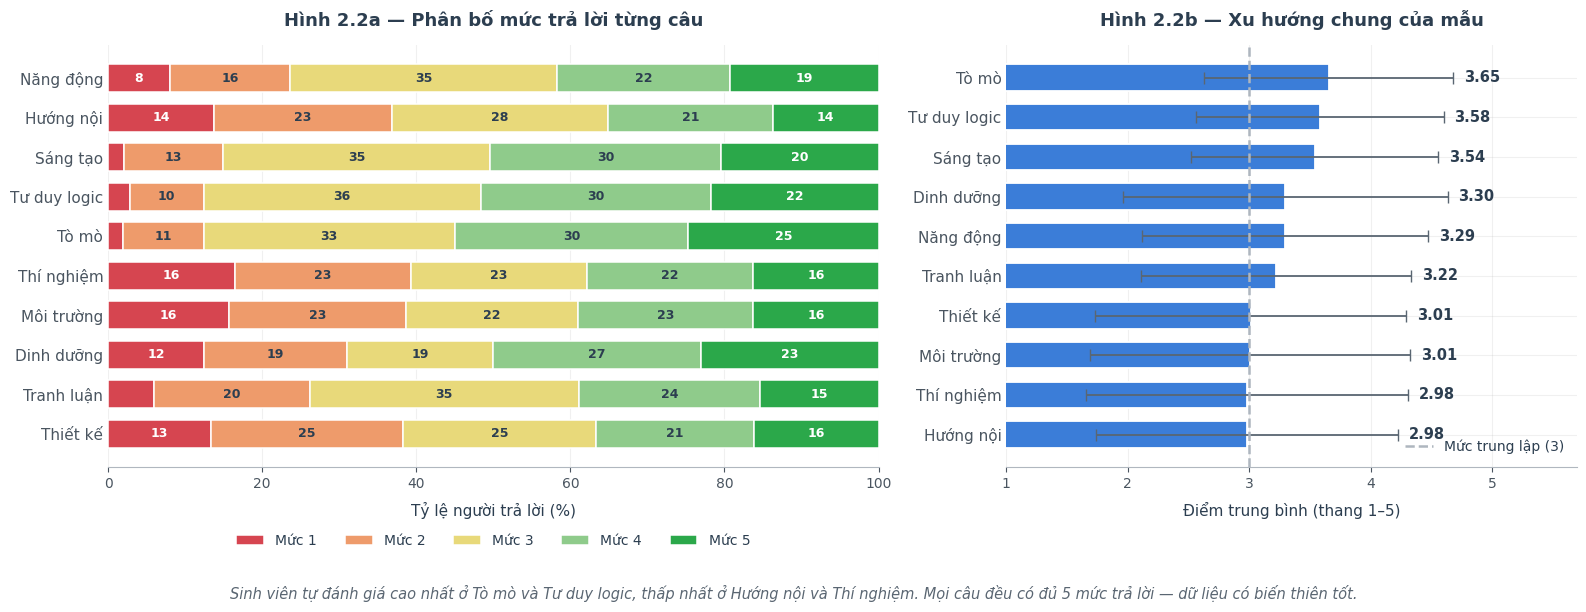

In [6]:
# ═══════════ HÌNH 2.2 — Phân bố trả lời 10 câu Likert ═══════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), gridspec_kw={"width_ratios": [1.35, 1]})

# (a) Biểu đồ cột chồng theo mức trả lời
ax = axes[0]
MAU_MUC = ["#D64550", "#EE9B6B", "#E8D97A", "#8FCB8B", "#2BA84A"]
day = np.zeros(10)
for muc in range(1, 6):
    ty_le = np.array([(df_clean[c] == muc).mean() * 100 for c in LIKERT_COLS])
    ax.barh(range(10), ty_le, left=day, height=0.7, color=MAU_MUC[muc - 1],
            edgecolor="white", linewidth=1.1, label=f"Mức {muc}")
    for i, (t, d) in enumerate(zip(ty_le, day)):
        if t >= 7:
            ax.text(d + t / 2, i, f"{t:.0f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if muc in (1, 5) else C_DAM)
    day += ty_le
ax.set_yticks(range(10)); ax.set_yticklabels(NHAN_LIKERT, fontsize=11)
ax.set_xlabel("Tỷ lệ người trả lời (%)"); ax.set_xlim(0, 100)
ax.set_title("Hình 2.2a — Phân bố mức trả lời từng câu")
ax.invert_yaxis(); ax.tick_params(axis="y", length=0)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=10)
ax.set_axisbelow(True); ax.grid(axis="x", alpha=0.18)

# (b) Trung bình ± độ lệch chuẩn
ax = axes[1]
tb = df_clean[LIKERT_COLS].mean().values
sd = df_clean[LIKERT_COLS].std().values
thu_tu = np.argsort(tb)
ax.barh(range(10), tb[thu_tu], xerr=sd[thu_tu], height=0.66, color=C_XANH,
        edgecolor="white", linewidth=1.3, error_kw={"ecolor": "#5A6672", "capsize": 4, "lw": 1.3})
for i, (v, s) in enumerate(zip(tb[thu_tu], sd[thu_tu])):
    ax.text(v + s + 0.09, i, f"{v:.2f}", va="center", fontsize=10.5, fontweight="bold", color=C_DAM)
ax.axvline(3, color=C_XAM, ls="--", lw=1.8, label="Mức trung lập (3)")
ax.set_yticks(range(10)); ax.set_yticklabels([NHAN_LIKERT[i] for i in thu_tu], fontsize=11)
ax.set_xlabel("Điểm trung bình (thang 1–5)"); ax.set_xlim(1, 5.7)
ax.set_title("Hình 2.2b — Xu hướng chung của mẫu")
ax.legend(loc="lower right"); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_2_2_phan_bo_likert.png",
    "Sinh viên tự đánh giá cao nhất ở Tò mò và Tư duy logic, thấp nhất ở Hướng nội và Thí nghiệm. "
    "Mọi câu đều có đủ 5 mức trả lời — dữ liệu có biến thiên tốt.")
plt.show()

   💾 Đã lưu hình: hinh_2_3_nhan_khau_hoc.png


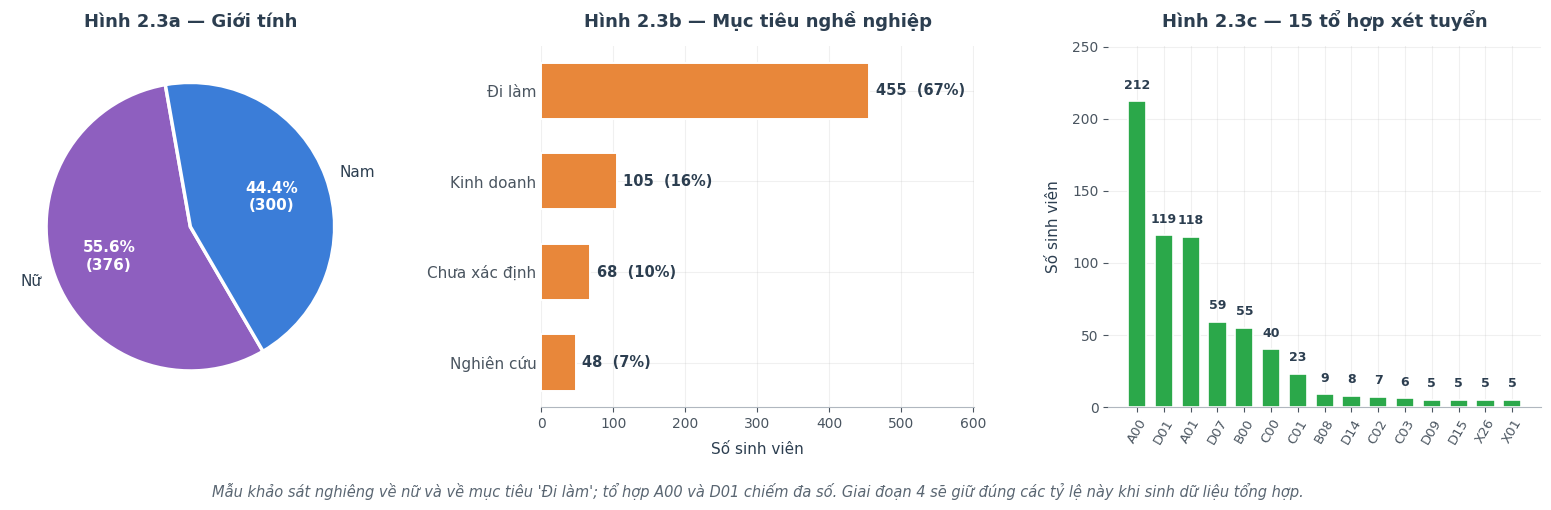

In [7]:
# ═══════════ HÌNH 2.3 — Nhân khẩu học ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# (a) Giới tính
ax = axes[0]
gt = df_clean["gioi_tinh"].value_counts()
w, t, a = ax.pie(gt.values, labels=gt.index, autopct=lambda p: f"{p:.1f}%\n({p*len(df_clean)/100:.0f})",
                 colors=[C_TIM, C_XANH], startangle=100, textprops={"fontsize": 11},
                 wedgeprops={"edgecolor": "white", "linewidth": 2.5})
for x in a: x.set_color("white"); x.set_fontweight("bold"); x.set_fontsize(11)
ax.set_title("Hình 2.3a — Giới tính")

# (b) Mục tiêu nghề nghiệp
ax = axes[1]
mt = df_clean["muc_tieu_nhan"].value_counts().sort_values()
ax.barh(range(len(mt)), mt.values, height=0.62, color=C_CAM, edgecolor="white", linewidth=1.4)
for i, v in enumerate(mt.values):
    ax.text(v + mt.max() * 0.02, i, f"{v}  ({v/len(df_clean):.0%})", va="center",
            fontsize=10.5, fontweight="bold", color=C_DAM)
ax.set_yticks(range(len(mt))); ax.set_yticklabels(mt.index, fontsize=11)
ax.set_xlim(0, mt.max() * 1.32); ax.set_xlabel("Số sinh viên")
ax.set_title("Hình 2.3b — Mục tiêu nghề nghiệp")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (c) Tổ hợp thi
ax = axes[2]
th = df_clean["to_hop_thi"].value_counts()
ax.bar(th.index, th.values, color=C_GA, width=0.68, edgecolor="white", linewidth=1.2)
nhan_doc(ax, "{:,.0f}", lui=0.03, fs=9)
ax.set_ylabel("Số sinh viên"); ax.set_ylim(0, th.max() * 1.18)
ax.tick_params(axis="x", rotation=60, labelsize=9.5)
ax.set_title(f"Hình 2.3c — {len(th)} tổ hợp xét tuyển")
ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_2_3_nhan_khau_hoc.png",
    "Mẫu khảo sát nghiêng về nữ và về mục tiêu 'Đi làm'; tổ hợp A00 và D01 chiếm đa số. "
    "Giai đoạn 4 sẽ giữ đúng các tỷ lệ này khi sinh dữ liệu tổng hợp.")
plt.show()

## 4. Tách Train / Test theo phân tầng

In [8]:
vc = df_clean["nganh_hoc"].value_counts()
assert vc.min() >= 2, f"Ngành có dưới 2 mẫu thì không chia phân tầng được: {vc[vc < 2].to_dict()}"

df_train, df_test = train_test_split(df_clean, test_size=TEST_SIZE,
                                     stratify=df_clean["nganh_hoc"], random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# --- Kiểm tra bắt buộc --------------------------------------------------------
assert len(df_train) + len(df_test) == len(df_clean)
assert df_train["nganh_hoc"].nunique() == 39, "Train phải đủ 39 ngành"
assert df_test["nganh_hoc"].nunique() == 39, "Test phải đủ 39 ngành"
assert set(df_train["ma_khoi_nganh"]) == set(range(7)) == set(df_test["ma_khoi_nganh"])

khoa = ["thoi_gian", "nganh_hoc", "gioi_tinh", "to_hop_thi"] + LIKERT_COLS
k_tr = set(map(tuple, df_train[khoa].astype(str).values))
k_te = set(map(tuple, df_test[khoa].astype(str).values))
assert not (k_tr & k_te), f"Có {len(k_tr & k_te)} dòng xuất hiện ở cả train lẫn test!"

print(f"TRAIN : {len(df_train):>4} phiếu  ({len(df_train)/len(df_clean):.1%})")
print(f"TEST  : {len(df_test):>4} phiếu  ({len(df_test)/len(df_clean):.1%})")
print(f"\n✅ Đủ 39 ngành và 7 khối ở cả hai tập; 0 dòng trùng nhau")
print(f"   Ngành ít mẫu nhất — train: {df_train['nganh_hoc'].value_counts().min()} phiếu, "
      f"test: {df_test['nganh_hoc'].value_counts().min()} phiếu")

TRAIN :  574 phiếu  (84.9%)
TEST  :  102 phiếu  (15.1%)

✅ Đủ 39 ngành và 7 khối ở cả hai tập; 0 dòng trùng nhau
   Ngành ít mẫu nhất — train: 5 phiếu, test: 1 phiếu


   💾 Đã lưu hình: hinh_2_4_phan_bo_train_test.png


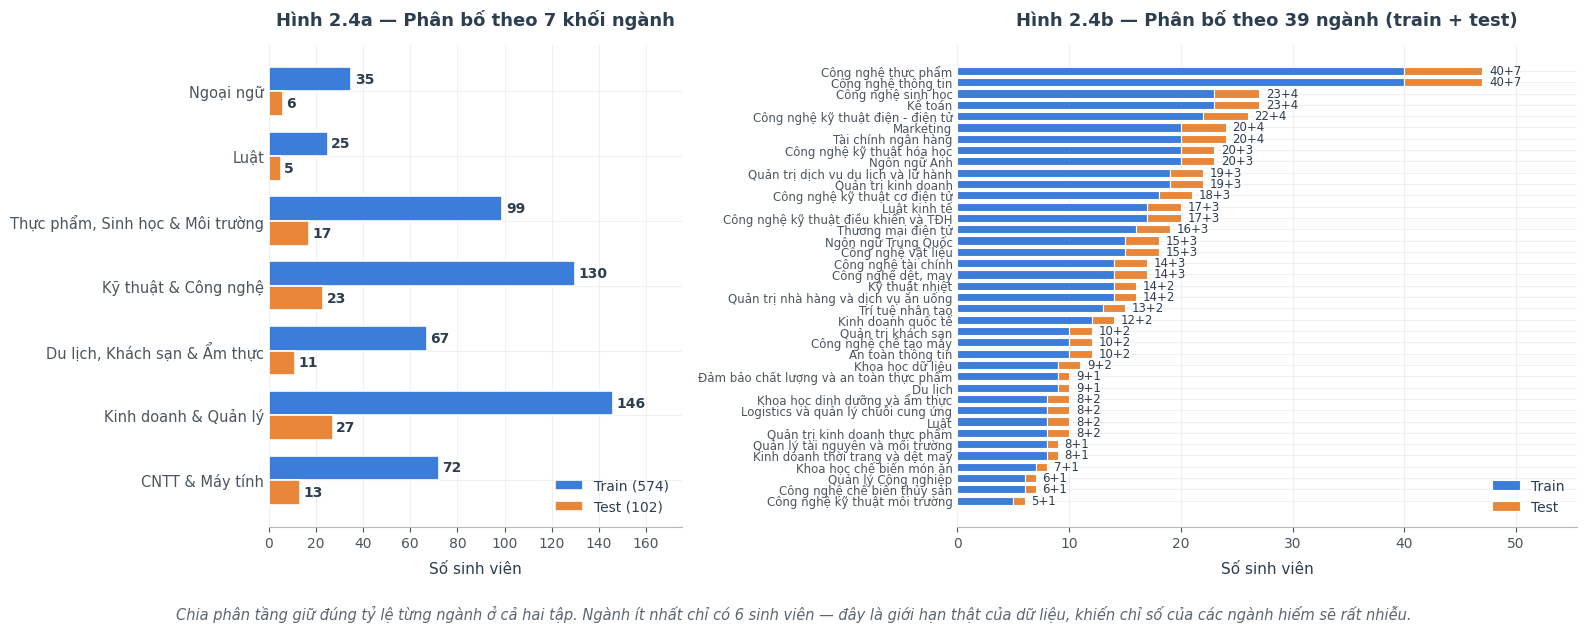

In [9]:
# ═══════════ HÌNH 2.4 — Phân bố Train / Test ═══════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.5]})

# (a) Theo 7 khối ngành
ax = axes[0]
tr = df_train["ma_khoi_nganh"].value_counts().sort_index()
te = df_test["ma_khoi_nganh"].value_counts().sort_index()
y = np.arange(7); h = 0.38
ax.barh(y + h/2, tr.values, h, label=f"Train ({len(df_train)})", color=C_XANH,
        edgecolor="white", linewidth=1.2)
ax.barh(y - h/2, te.values, h, label=f"Test ({len(df_test)})", color=C_CAM,
        edgecolor="white", linewidth=1.2)
for i in range(7):
    ax.text(tr.values[i] + 1.5, i + h/2, f"{tr.values[i]}", va="center", fontsize=10, fontweight="bold")
    ax.text(te.values[i] + 1.5, i - h/2, f"{te.values[i]}", va="center", fontsize=10, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels([TEN_KHOI[i] for i in range(7)], fontsize=10.5)
ax.set_xlabel("Số sinh viên"); ax.set_xlim(0, tr.max() * 1.2)
ax.set_title("Hình 2.4a — Phân bố theo 7 khối ngành")
ax.legend(loc="lower right"); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (b) Theo 39 ngành
ax = axes[1]
bang = pd.DataFrame({"train": df_train["nganh_hoc"].value_counts(),
                     "test": df_test["nganh_hoc"].value_counts()}).fillna(0).astype(int)
bang["tong"] = bang.sum(axis=1)
bang = bang.sort_values("tong")
y = np.arange(39)
ax.barh(y, bang["train"], height=0.72, color=C_XANH, edgecolor="white", linewidth=0.8, label="Train")
ax.barh(y, bang["test"], left=bang["train"], height=0.72, color=C_CAM,
        edgecolor="white", linewidth=0.8, label="Test")
for i, (a, b) in enumerate(zip(bang["train"], bang["test"])):
    ax.text(a + b + 0.6, i, f"{a}+{b}", va="center", fontsize=8.5, color=C_DAM)
ax.set_yticks(y); ax.set_yticklabels(bang.index, fontsize=8.5)
ax.set_xlabel("Số sinh viên"); ax.set_xlim(0, bang["tong"].max() * 1.18)
ax.set_title("Hình 2.4b — Phân bố theo 39 ngành (train + test)")
ax.legend(loc="lower right"); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_2_4_phan_bo_train_test.png",
    f"Chia phân tầng giữ đúng tỷ lệ từng ngành ở cả hai tập. Ngành ít nhất chỉ có "
    f"{bang['tong'].min()} sinh viên — đây là giới hạn thật của dữ liệu, "
    f"khiến chỉ số của các ngành hiếm sẽ rất nhiễu.")
plt.show()

## 5. Thiết kế Cross-Validation

`RepeatedStratifiedKFold(5 fold × 3 lần)` cho **15 lần đo**. Lấy trung bình ± độ lệch chuẩn để chỉ
số ổn định, vì mỗi tập validation chỉ có ~115 dòng thật nên đo một lần là quá nhiễu.

Chỉ số fold được **lưu ra file** để Giai đoạn 8 dùng đúng bộ chia này — đảm bảo mọi mô hình
(baseline, model phẳng, mô hình 2 tầng) đều được so sánh trên cùng một điều kiện.

In [10]:
y_strat = df_train["nganh_hoc"].values
it_nhat = pd.Series(y_strat).value_counts().min()
assert it_nhat >= N_SPLITS, f"Ngành ít nhất chỉ có {it_nhat} mẫu < {N_SPLITS} fold"

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
folds = [{"fold": i, "repeat": i // N_SPLITS, "train_idx": tr.tolist(), "val_idx": va.tolist()}
         for i, (tr, va) in enumerate(rskf.split(np.zeros(len(y_strat)), y_strat))]

with open(OUTPUT_DIR / "cv_folds_real.json", "w", encoding="utf-8") as f:
    json.dump({"n_splits": N_SPLITS, "n_repeats": N_REPEATS, "random_state": SEED,
               "n_train_real": len(df_train), "stratify_by": "nganh_hoc", "folds": folds}, f, indent=1)

dem = np.zeros(len(df_train), dtype=int)
for fo in folds:
    dem[fo["val_idx"]] += 1
assert (dem == N_REPEATS).all(), "Mỗi dòng phải nằm trong VAL đúng n_repeats lần"

sizes = [len(fo["val_idx"]) for fo in folds]
print(f"✅ Đã tạo {len(folds)} fold ({N_SPLITS} phần × {N_REPEATS} lần lặp)")
print(f"   Mỗi fold — VAL  : {min(sizes)}–{max(sizes)} dòng thật")
print(f"   Mỗi fold — TRAIN: {len(df_train)-max(sizes)}–{len(df_train)-min(sizes)} dòng thật")
print(f"                     (+ dữ liệu tổng hợp sẽ thêm vào ở Giai đoạn 8)")
print(f"   ✔ Mỗi dòng train được dùng làm VAL đúng {N_REPEATS} lần")

✅ Đã tạo 15 fold (5 phần × 3 lần lặp)
   Mỗi fold — VAL  : 114–115 dòng thật
   Mỗi fold — TRAIN: 459–460 dòng thật
                     (+ dữ liệu tổng hợp sẽ thêm vào ở Giai đoạn 8)
   ✔ Mỗi dòng train được dùng làm VAL đúng 3 lần


   💾 Đã lưu hình: hinh_2_5_thiet_ke_cross_validation.png


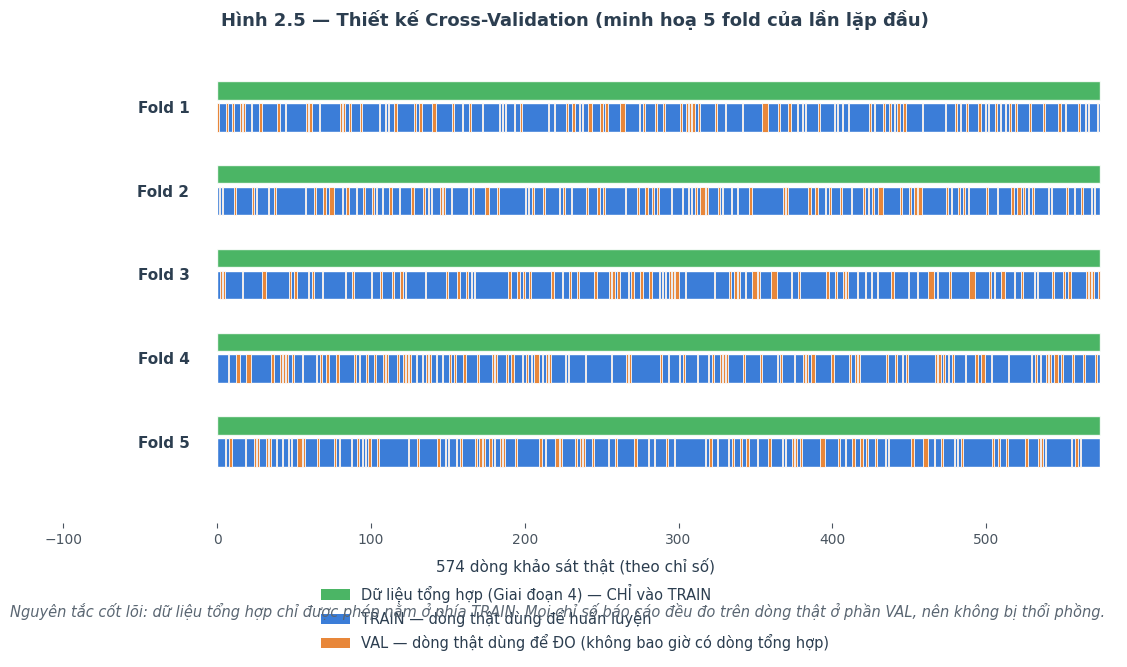

In [11]:
# ═══════════ HÌNH 2.5 — Sơ đồ thiết kế Cross-Validation ═══════════
fig, ax = plt.subplots(figsize=(14, 6.2))

N_VE = N_SPLITS   # vẽ 5 fold của lần lặp đầu cho dễ nhìn
rong = len(df_train)
for i in range(N_VE):
    fo = folds[i]
    va = set(fo["val_idx"])
    y0 = N_VE - i - 1
    # phần TRAIN thật
    ax.add_patch(Rectangle((0, y0 + 0.12), rong, 0.34, facecolor=C_XANH, edgecolor="white", lw=1))
    # phần VAL (vẽ đúng vị trí khối val)
    bat_dau = min(va); ket_thuc = max(va)
    xs = sorted(va)
    # gom thành các đoạn liên tục để vẽ
    doan, s = [], xs[0]
    for a, b in zip(xs, xs[1:] + [None]):
        if b is None or b != a + 1:
            doan.append((s, a)); s = b
    for a, b in doan:
        ax.add_patch(Rectangle((a, y0 + 0.12), b - a + 1, 0.34,
                               facecolor=C_CAM, edgecolor="white", lw=0.6))
    # phần dữ liệu tổng hợp
    ax.add_patch(Rectangle((0, y0 + 0.50), rong, 0.22, facecolor=C_GA,
                           edgecolor="white", lw=1, alpha=0.85))
    ax.text(-18, y0 + 0.4, f"Fold {i+1}", ha="right", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(-120, rong * 1.02); ax.set_ylim(-0.55, N_VE + 0.15)
# Lề trái âm chỉ để chừa chỗ ghi "Fold N"; không đánh vạch ở đó vì không có
# dòng nào mang chỉ số âm.
ax.set_xticks(range(0, rong + 1, 100))
ax.set_xlabel("574 dòng khảo sát thật (theo chỉ số)")
ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Hình 2.5 — Thiết kế Cross-Validation (minh hoạ 5 fold của lần lặp đầu)")
ax.legend(handles=[
    Patch(facecolor=C_GA, alpha=0.85, label="Dữ liệu tổng hợp (Giai đoạn 4) — CHỈ vào TRAIN"),
    Patch(facecolor=C_XANH, label="TRAIN — dòng thật dùng để huấn luyện"),
    Patch(facecolor=C_CAM, label="VAL — dòng thật dùng để ĐO (không bao giờ có dòng tổng hợp)"),
], loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1, fontsize=10.5)

luu(fig, OUTPUT_DIR, "hinh_2_5_thiet_ke_cross_validation.png",
    "Nguyên tắc cốt lõi: dữ liệu tổng hợp chỉ được phép nằm ở phía TRAIN. "
    "Mọi chỉ số báo cáo đều đo trên dòng thật ở phần VAL, nên không bị thổi phồng.")
plt.show()

In [12]:
# --- Xuất file ----------------------------------------------------------------
df_train.to_csv(OUTPUT_DIR / "khaosat_train.csv", index=False, encoding="utf-8-sig")
df_test.to_csv(OUTPUT_DIR / "khaosat_test_KHONG_DUNG_TOI.csv", index=False, encoding="utf-8-sig")

print("═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 2")
print("═" * 68)
print(f"  Phiếu khảo sát ban đầu       {len(df_raw):>10,}")
print(f"  Loại phiếu điền đại          {int(nhieu.sum()):>10,}   ({nhieu.mean():.1%})")
print(f"  Phiếu chất lượng             {len(df_clean):>10,}")
print(f"  ├─ TRAIN                     {len(df_train):>10,}   ({len(df_train)/len(df_clean):.1%})")
print(f"  └─ TEST (khoá lại)           {len(df_test):>10,}   ({len(df_test)/len(df_clean):.1%})")
print(f"  Số fold Cross-Validation     {len(folds):>10}   ({N_SPLITS} × {N_REPEATS})")
print(f"  Số ngành / khối              {df_clean['nganh_hoc'].nunique():>10} / 7")
print("═" * 68)
print(f"\n  ⚠️  khaosat_test_KHONG_DUNG_TOI.csv sẽ KHÔNG được mở cho tới Giai đoạn 8.")
print(f"  Hình đã lưu tại: {OUTPUT_DIR}/")

════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 2
════════════════════════════════════════════════════════════════════
  Phiếu khảo sát ban đầu              766
  Loại phiếu điền đại                  90   (11.7%)
  Phiếu chất lượng                    676
  ├─ TRAIN                            574   (84.9%)
  └─ TEST (khoá lại)                  102   (15.1%)
  Số fold Cross-Validation             15   (5 × 3)
  Số ngành / khối                      39 / 7
════════════════════════════════════════════════════════════════════

  ⚠️  khaosat_test_KHONG_DUNG_TOI.csv sẽ KHÔNG được mở cho tới Giai đoạn 8.
  Hình đã lưu tại: ../data/processed/02_split/
